<a href="https://colab.research.google.com/github/swetha343452-code/MACHINE-LEARNING/blob/main/image%20processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

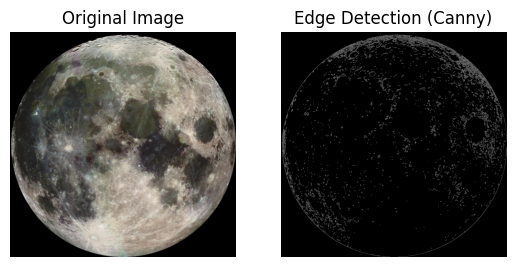

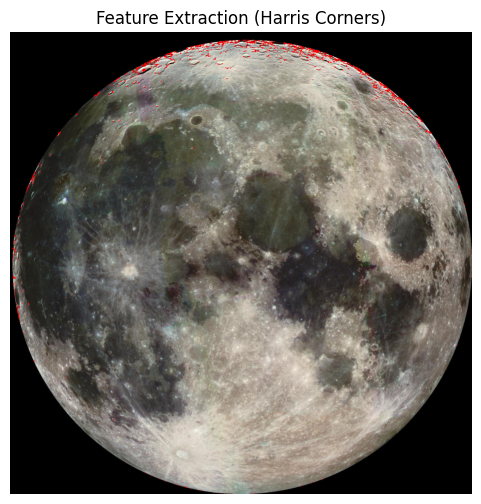

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Load the image
image = cv2.imread('/content/moon.jpg')  # Replace with your image path

# Check if image is loaded successfully
if image is None:
    print("Error: Image not found!")
    exit()

# Step 2: Convert the image to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Step 3: Apply Edge Detection (Canny)
edges = cv2.Canny(gray_image, threshold1=100, threshold2=200)

# Step 4: Feature Extraction using Harris Corner Detection

# Convert grayscale image to float32
gray_float = np.float32(gray_image)

# Detect corners
dst = cv2.cornerHarris(gray_float, 2, 3, 0.04)

# Dilate the result to mark corners
dst = cv2.dilate(dst, None)

# Step 5: Mark the corners on the original image
image_with_corners = image.copy()
image_with_corners[dst > 0.01 * dst.max()] = [0, 0, 255]  # Red color

# Step 6: Display the results

# Original Image
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')

# Edge Detection Result
plt.subplot(1, 2, 2)
plt.imshow(edges, cmap='gray')
plt.title("Edge Detection (Canny)")
plt.axis('off')

plt.show()

# Feature Extraction (Corners)
plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(image_with_corners, cv2.COLOR_BGR2RGB))
plt.title("Feature Extraction (Harris Corners)")
plt.axis('off')

plt.show()